In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage
import dicom_utils

In [19]:
def cc3d(lung_mask0):
    minimum_cc_sum = np.sum(lung_mask0)*0.4
    minimum_tot_sum = np.sum(lung_mask0)*0.65
    minimum_cc2_sum = np.sum(lung_mask0)*0.3
    lung_mask = lung_mask0.copy()

    # Let us create a binary mask.
    binary_mask = np.round(lung_mask).astype('int')

    # Now, we perform region labelling. This way, every connected component
    # will have their own colour value.
    labelled_mask, num_labels = ndimage.label(binary_mask)

    # Let us now remove all the too small regions.
    for lab in range(num_labels+1):
        if np.sum(lung_mask[labelled_mask == lab]) < minimum_cc_sum:
            lung_mask[labelled_mask == lab] = 0

    if np.sum(lung_mask) < minimum_tot_sum:
        lung_mask = lung_mask0.copy()
        for lab in range(num_labels+1):
            if np.sum(lung_mask[labelled_mask == lab]) < minimum_cc2_sum:
                lung_mask[labelled_mask == lab] = 0

    return np.round(lung_mask)

In [32]:
fill_voids = lambda mask: ndimage.binary_fill_holes(mask).astype(int)

In [20]:
roi = np.load('/media/bendico765/Crucial X9/MRI Lesions/Roi masks/AMBL-562/ROI 0.npy')
z = 76

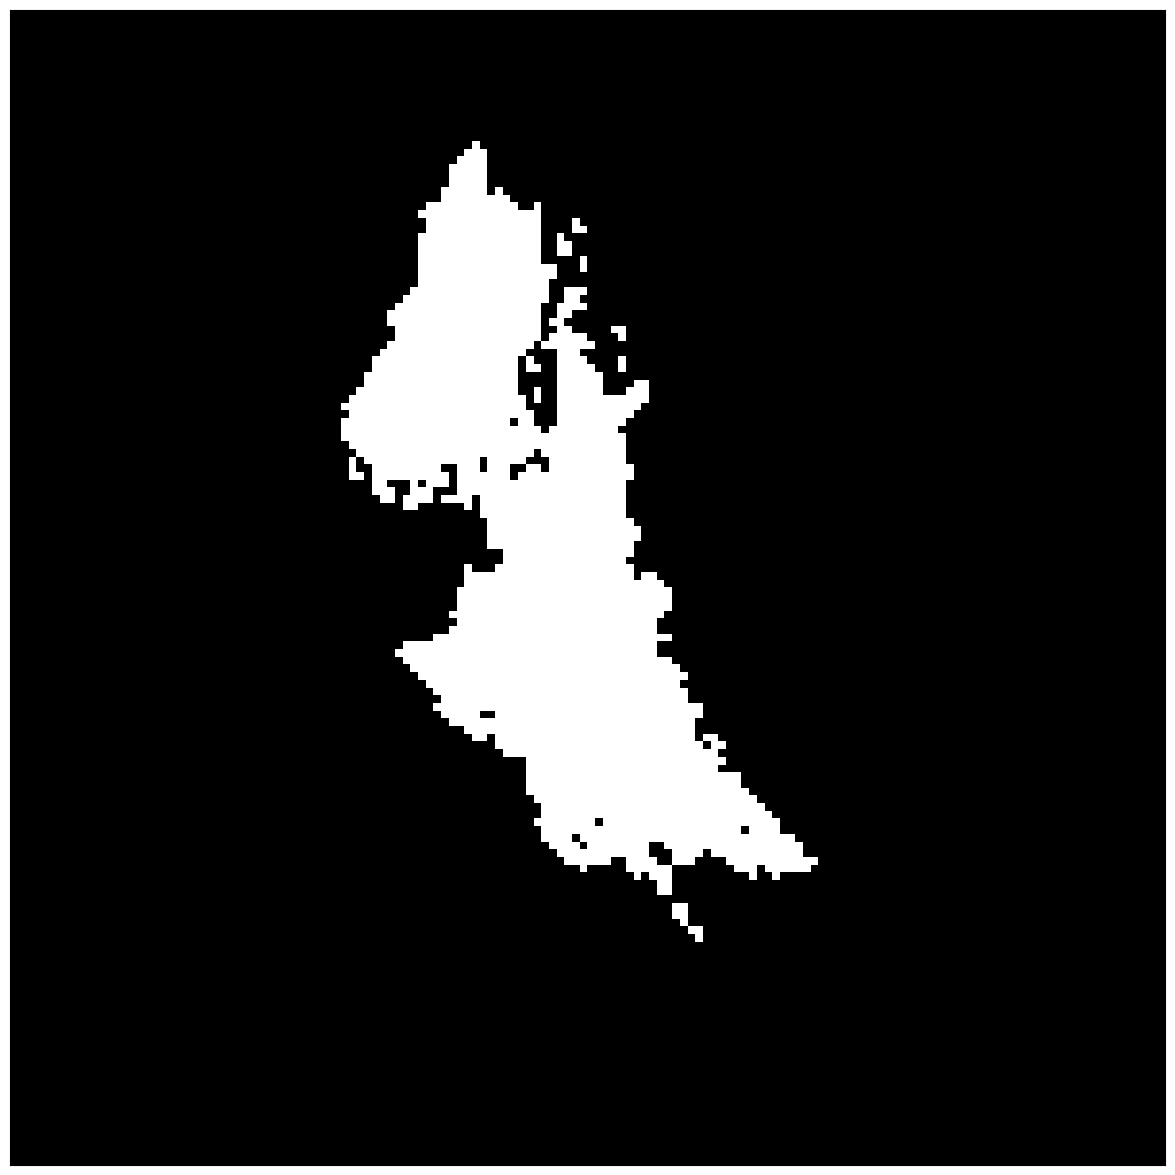

In [33]:
fig = plt.figure(figsize=(15,15))

plt.xticks([])
plt.yticks([])

plt.imshow(roi[z][125:275, 325:475], cmap = plt.cm.grey)
plt.savefig("/media/bendico765/Crucial X9/MRI Lesions/figures/mask_preprocessing_original.png")

plt.imshow(ndimage.binary_dilation(roi)[z][125:275, 325:475], cmap = plt.cm.grey)
plt.savefig("/media/bendico765/Crucial X9/MRI Lesions/figures/mask_preprocessing_dilation.png")

plt.imshow(cc3d(ndimage.binary_dilation(roi))[z][125:275, 325:475], cmap = plt.cm.grey)
plt.savefig("/media/bendico765/Crucial X9/MRI Lesions/figures/mask_preprocessing_dilation_removaldisccomponents.png")

plt.imshow(fill_voids(cc3d(ndimage.binary_dilation(roi)))[z][125:275, 325:475], cmap = plt.cm.grey)
plt.savefig("/media/bendico765/Crucial X9/MRI Lesions/figures/mask_preprocessing_dilation_removaldisccomponents_voidsfilled.png")

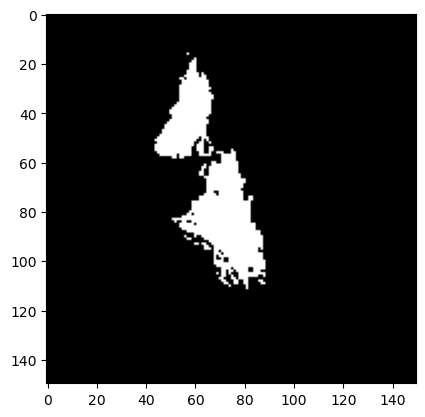

In [35]:
plt.imshow(roi[z][125:275, 325:475], cmap = plt.cm.grey)
plt.show()

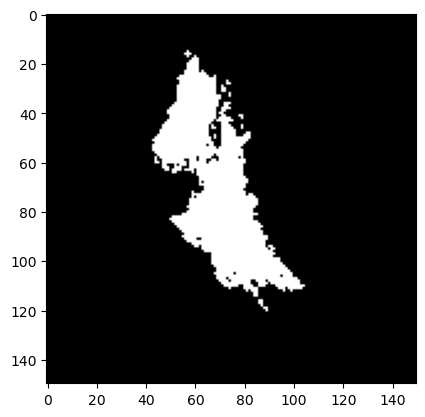

In [36]:
plt.imshow(ndimage.binary_dilation(roi)[z][125:275, 325:475], cmap = plt.cm.grey)
plt.show()

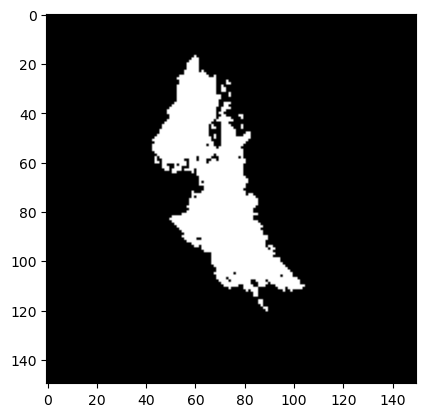

In [37]:
plt.imshow(cc3d(ndimage.binary_dilation(roi))[z][125:275, 325:475], cmap = plt.cm.grey)
plt.show()

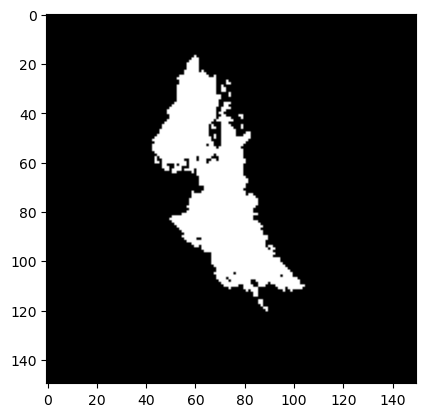

In [38]:
plt.imshow(fill_voids(cc3d(ndimage.binary_dilation(roi)))[z][125:275, 325:475], cmap = plt.cm.grey)
plt.show()

In [11]:
ph1, ph2, ph3, ph4, ph5 = dicom_utils.get_multiphase_mri("/media/bendico765/Crucial X9/MRI Lesions/manifest-1728494830954/Advanced-MRI-Breast-Lesions/AMBL-001/03-05-2004-NA-MRI BREASTS - Delayed contrast-93547/500.000000-Registered AX Sen Vibrant MultiPhase-85715")
roi = np.load("/media/bendico765/Crucial X9/MRI Lesions/Cleaned Roi masks/AMBL-001/ROI 0.npy")

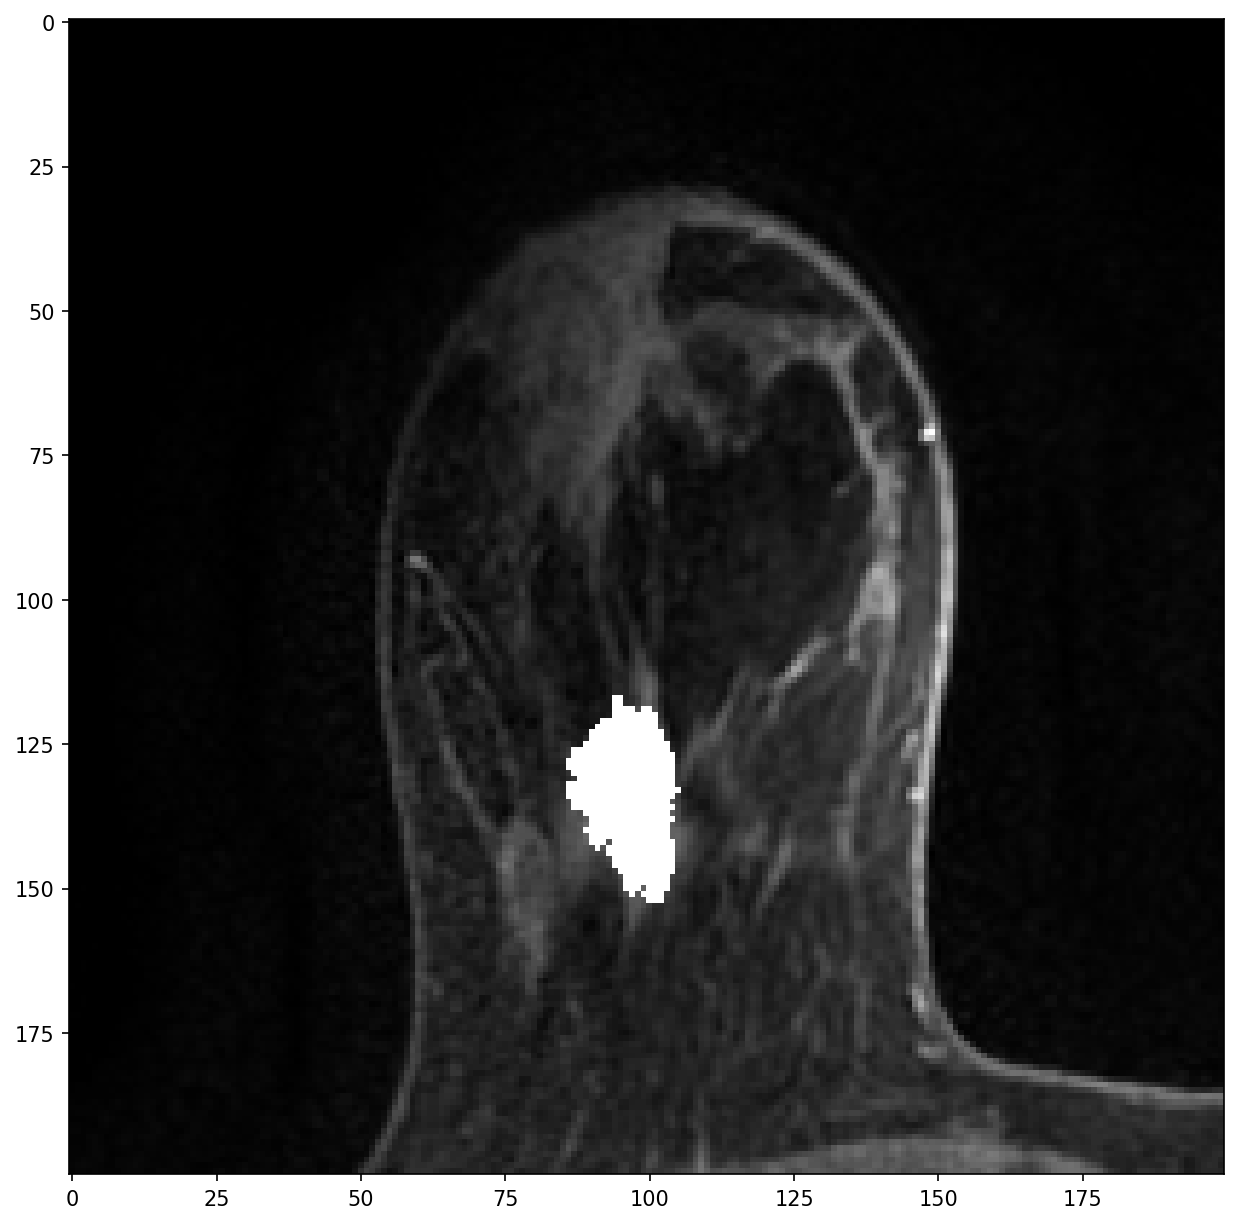

In [29]:
i = 5
plt.figure(figsize = (10,10), dpi=150)
plt.imshow(ph5[83, 60:260, 60:260], cmap=plt.cm.gray)
plt.imshow(roi[83,60:260,60:260], cmap=plt.cm.gray, alpha=(roi[83,60:260,60:260] > 0).astype(float) )
plt.savefig(f"/home/bendico765/Desktop/multiphase_{i}")